# Analysis
1. Data Loading and Environment Setup
2. Initial data exploration
3. Data Quality revision
4. Descriptive Statistics
5. Feature Engineering and Department-Level Analysis
6. Retention Analysis by Major
7. Impact internship duration on Retention
9. Impact of Supervisor Evalution on Retention
10. Salary Analysis and Retention
11. Age Analysis and Retention
12. Department Retention Analysis
13. Interactive Data Exploration
14. Supervisor Evaluation vs Internship Duration
15. Final Data Preparation
16. (Optional) Encoding Techniques

# 1. Data Loading and Environment Setup

In [1]:
#import libraries needed

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from ipywidgets import interact
import seaborn as sns
from sklearn.preprocessing import OneHotEncoder
from category_encoders import TargetEncoder
#pip install category-encoders
# https://ipywidgets.readthedocs.io/en/stable/examples/Widget%20List.html
# pip install ipywidgets
# from widgets import interact

In [2]:
# Loading Dataset from a CSV file and create it
df = pd.read_csv(r"C:\Users\s3rgi\OneDrive\Área de Trabalho\intern-retention-project\Project\data\processed\HR-Intern-Retention_processed.csv")

# Create a dataset backup
df_copy = df.copy()

# 2. Initial data exploration

In [3]:
#Information of data type and measure (quantity of rows and columns).
df.shape
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 9 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   Intern_ID                   200 non-null    int64  
 1   Age                         200 non-null    int64  
 2   Major                       200 non-null    str    
 3   Internship_Duration_Months  200 non-null    int64  
 4   Department                  200 non-null    str    
 5   Supervisor_Evaluation       200 non-null    float64
 6   Salary                      200 non-null    int64  
 7   Attendance_%                200 non-null    float64
 8   Retained                    200 non-null    int64  
dtypes: float64(2), int64(5), str(2)
memory usage: 14.2 KB


# 3. Data Quality Assessment

In [4]:
# Number of nulls
df.isna().sum()

Intern_ID                     0
Age                           0
Major                         0
Internship_Duration_Months    0
Department                    0
Supervisor_Evaluation         0
Salary                        0
Attendance_%                  0
Retained                      0
dtype: int64

In [5]:
# Confirm duplicate
df.duplicated().sum()

np.int64(0)

# 4. Descriptive Statistics

In [6]:
# Supervisors reported that the minimum evaluation score was 1.10, the maximum was 5.00, and the overall average evaluation score is 2.88.
df.describe()

df[["Age", "Internship_Duration_Months", "Supervisor_Evaluation", "Salary", "Attendance_%"]].describe()

,Age,Internship_Duration_Months,Supervisor_Evaluation,Salary,Attendance_%
count,200.000000,200.000000,200.000000,200.000000,200.000000
mean,24.010000,12.245000,2.886500,1424.650000,81.386500
std,3.488661,6.772318,1.120915,360.800586,11.918107
min,18.000000,1.000000,1.100000,803.000000,60.700000
25%,21.000000,5.750000,1.875000,1112.000000,70.300000
50%,24.000000,12.000000,2.850000,1472.000000,82.950000
75%,27.000000,18.000000,3.900000,1736.500000,92.325000
max,29.000000,23.000000,5.000000,1998.000000,99.900000


We remove Intern_ID and Retained because they're irrelevant for analysis. 

# 5. Feature Engineering and Department-Level Analysis

In [7]:
df["Salary_Attendance_ratio"] = (df["Salary"] / df["Attendance_%"]).round(2)
df.head()

df.sort_values(by="Salary_Attendance_ratio", ascending=True).head(30)

df

,Intern_ID,Age,Major,Internship_Duration_Months,Department,Supervisor_Evaluation,Salary,Attendance_%,Retained,Salary_Attendance_ratio
0,1,24,IT,20,Legal,1.8,1956,71.9,1,27.20
1,2,21,Law,15,HR,1.2,1687,82.7,0,20.40
2,3,28,Engineering,3,HR,1.7,926,79.0,0,11.72
3,4,25,IT,23,Marketing,2.1,1929,86.5,1,22.30
4,5,22,Engineering,8,Legal,1.7,1808,97.5,1,18.54
...,...,...,...,...,...,...,...,...,...,...
195,196,26,IT,8,Finance,3.4,948,73.4,1,12.92
196,197,22,IT,16,Finance,1.1,810,89.7,1,9.03
197,198,18,Marketing,13,Marketing,4.5,1475,66.4,1,22.21
198,199,20,IT,1,IT,4.7,1936,92.7,0,20.88


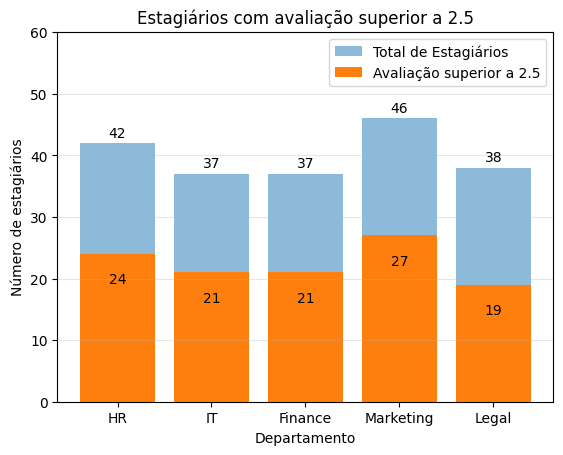

In [8]:
# Department analysis with supervisor evalution
#display(df_drop.groupby("Department")["Supervisor_Evaluation"].describe())

# Total trainees in Departament
total_department = df["Department"].value_counts()
total_hr = len(df.loc[df["Department"] == "HR"])
total_it = len(df.loc[df["Department"] == "IT"])
total_finance = len(df.loc[df["Department"] == "Finance"])
total_marketing = len(df.loc[df["Department"] == "Marketing"])
total_legal = len(df.loc[df["Department"] == "Legal"])

#display(df[df["Department"] == "HR"].groupby("Supervisor_Evaluation")["Department"].value_counts())

df["Evaluation_Flag"] = df["Supervisor_Evaluation"] >= 2.5

evaluation_hr = len(df.loc[(df["Department"] == "HR") & (df["Supervisor_Evaluation"] > 2.5)])
evaluation_it = len(df.loc[(df["Department"] == "IT") & (df["Supervisor_Evaluation"] > 2.5)])
evaluation_finance = len(df.loc[(df["Department"] == "Finance") & (df["Supervisor_Evaluation"] > 2.5)])
evaluation_marketing = len(df.loc[(df["Department"] == "Marketing") & (df["Supervisor_Evaluation"] > 2.5)])
evaluation_legal = len(df.loc[(df["Department"] == "Legal") & (df["Supervisor_Evaluation"] > 2.5)])


data_total = {
    "HR": total_hr,
    "IT": total_it,
    "Finance": total_finance,
    "Marketing": total_marketing,
    "Legal": total_legal
}

data_evaluation = {
    "HR": evaluation_hr,
    "IT": evaluation_it,
    "Finance": evaluation_finance,
    "Marketing": evaluation_marketing,
    "Legal": evaluation_legal    
}

plt.figure()
plt.grid(alpha=0.3, axis="y")
plt.bar(data_total.keys(), data_total.values(), alpha=0.5, label="Total de Estagiários")
plt.bar(data_evaluation.keys(), data_evaluation.values(), label="Avaliação superior a 2.5")
plt.xlabel("Departamento")
plt.ylabel("Número de estagiários")

# numbers on bars
for x, y in enumerate(data_total.values()):
    plt.text(x, y + 1, str(y), ha='center')

for x, y in enumerate(data_evaluation.values()):
    plt.text(x, y - 3, str(y), ha='center', va='top', color="black")

plt.title("Estagiários com avaliação superior a 2.5")
plt.ylim(0, 60)
plt.legend()
plt.show()

#A new column was created to classify trainees based on supervisor evaluation. Scores below 2.5 are labeled as False, while scores equal to or above 2.5 are labeled as True.   

### Department Analysis by Supervisor Evaluation (Average ≥ 2.5)

* *There is no significant discrepancy in the number of interns with average scores equal to or above 2.5 across departments.*
* *The Marketing department has the highest number of interns (46) and also the highest number of above-average evaluations, with 27 interns.*
* *The Legal department has the lowest number of above-average evaluations, with 19 out of a total of 38 interns.*

# 6. Retention Analysis by Major

<StringArray>
['IT', 'Law', 'Engineering', 'Business', 'Marketing']
Length: 5, dtype: str

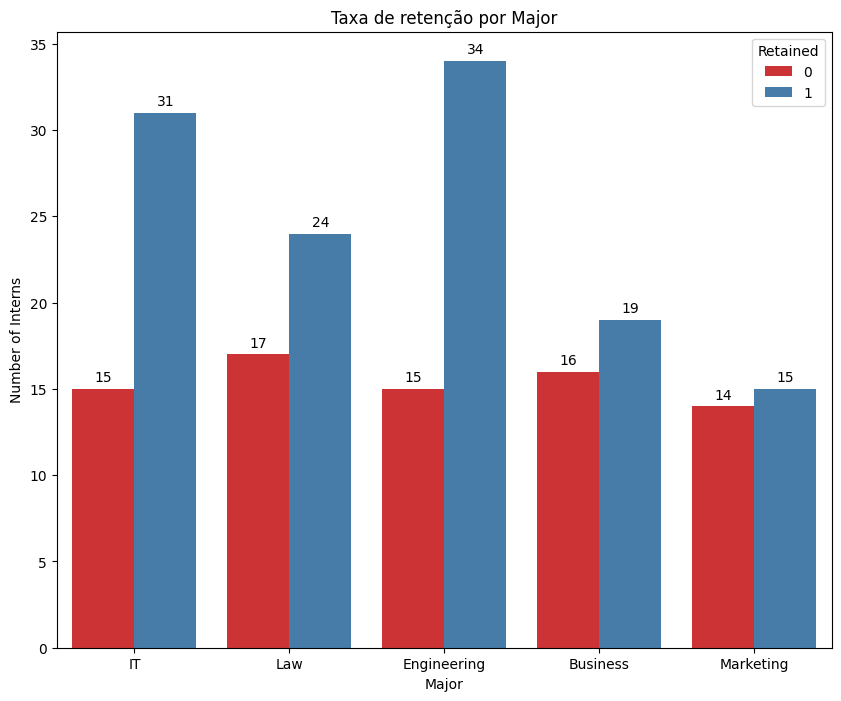

C:\Users\s3rgi\AppData\Local\Temp\ipykernel_31452\1992669854.py:36: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ox = sns.barplot(data=df_major_retention, x="Major", y="Retention_Rate", palette="Set1")


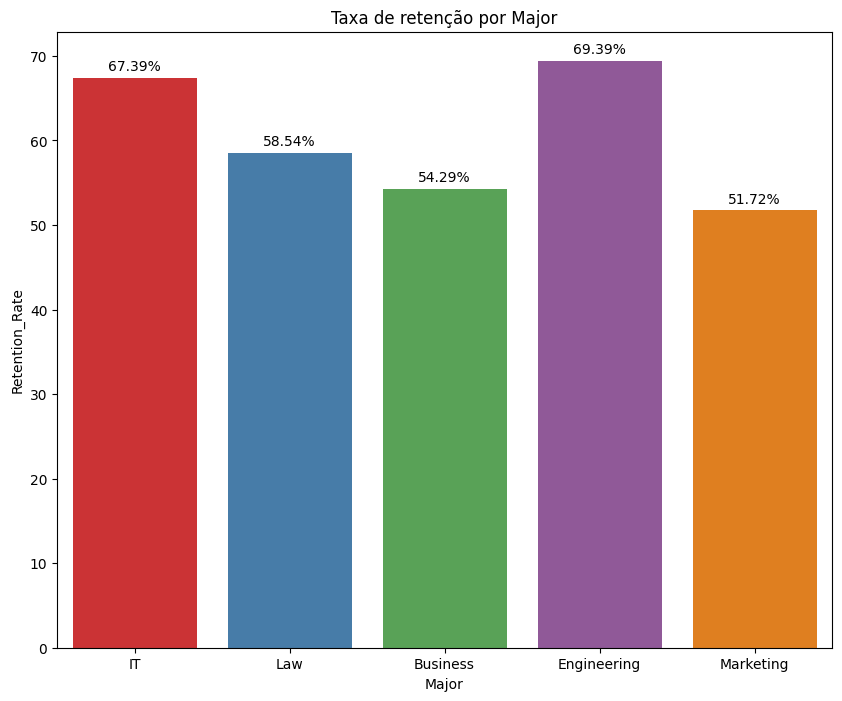

In [9]:
#  Which major has the highest retention rate?
display(df["Major"].unique())

# Number of interns in each major
it_major = len(df.loc[df["Major"] == "IT"])
law_major = len(df.loc[df["Major"] == "Law"])
business_major = len(df.loc[df["Major"] == "Business"])
engineering_major = len(df.loc[df["Major"] == "Engineering"])
marketing_major = len(df.loc[df["Major"] == "Marketing"])

# percentage of interns retained in each major
it_retained = len(df.loc[(df["Major"] == "IT") & (df["Retained"] == 1)]) / it_major * 100   
law_retained = len(df.loc[(df["Major"] == "Law") & (df["Retained"] == 1)]) / law_major * 100
business_retained = len(df.loc[(df["Major"] == "Business") & (df["Retained"] == 1)]) / business_major * 100
engineering_retained = len(df.loc[(df["Major"] == "Engineering") & (df["Retained"] == 1)]) / engineering_major * 100
marketing_retained = len(df.loc[(df["Major"] == "Marketing") & (df["Retained"] == 1)]) / marketing_major * 100


df_major_retention = pd.DataFrame({
    "Major": ["IT", "Law", "Business", "Engineering", "Marketing"],
    "Retention_Rate": [it_retained, law_retained, business_retained, engineering_retained, marketing_retained]
})

plt.figure(figsize=(10, 8))
ax = sns.countplot(data=df, x="Major", hue="Retained", palette="Set1")

for container in ax.containers:
    ax.bar_label(container, padding=3)

plt.title("Taxa de retenção por Major")
plt.ylabel("Number of Interns")
plt.xlabel("Major")
plt.show()

plt.figure(figsize=(10,8))
ox = sns.barplot(data=df_major_retention, x="Major", y="Retention_Rate", palette="Set1")
for container in ox.containers:
    ox.bar_label(container, fmt="%.2f%%", padding=3)
plt.title("Taxa de retenção por Major")
plt.show()



###  Which major has the highest retention rate?
*The major with the highest retention rate is Engineering, at 63.39%. The major with the lowest retention rate is Marketing, at 51.72%.*

# 7. Impact of internship duration on Retention

C:\Users\s3rgi\AppData\Local\Temp\ipykernel_31452\3493235127.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x="Retained", y="Internship_Duration_Months", data=df, palette="Set1")


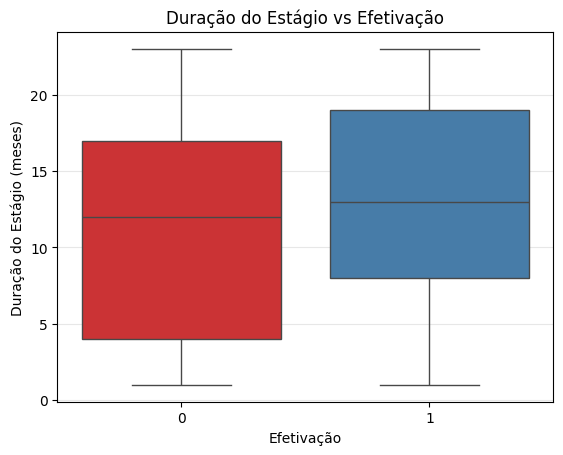

In [10]:
# Does the internship duration influence intern retention?

df.groupby("Retained")["Internship_Duration_Months"].mean()

sns.boxplot(x="Retained", y="Internship_Duration_Months", data=df, palette="Set1")

plt.xlabel("Efetivação")
plt.grid(axis='y', alpha=0.3)
plt.ylabel("Duração do Estágio (meses)")
plt.title("Duração do Estágio vs Efetivação")

plt.show()



# Does the duration of the internship influence the intern's chances of being hired permanently?
*Looking at the data, we see that longer internships increase the chance of retention.*

# 8. Impact of Supervisor Evaluation on Retention

C:\Users\s3rgi\AppData\Local\Temp\ipykernel_31452\3877684561.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x="Retained", y="Supervisor_Evaluation", data=df, palette="Set1")


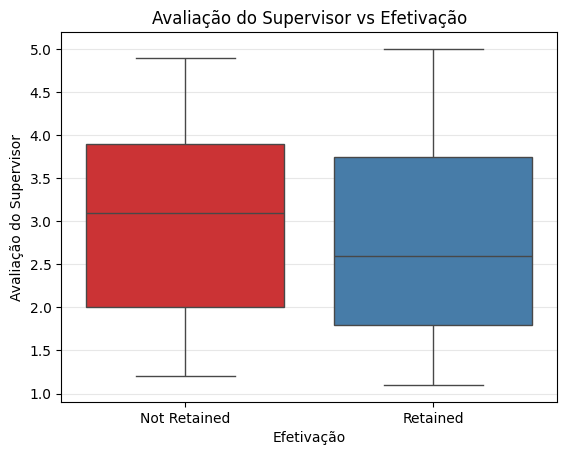

In [11]:

df.groupby("Retained")["Supervisor_Evaluation"].mean()

sns.boxplot(x="Retained", y="Supervisor_Evaluation", data=df, palette="Set1")

plt.xlabel("Efetivação")
plt.grid(axis='y', alpha=0.3)
plt.xticks([0,1], ["Not Retained","Retained"])
plt.ylabel("Avaliação do Supervisor")
plt.title("Avaliação do Supervisor vs Efetivação")

plt.show()

### Supervisor Evaluation vs. Retention ###
*By visualizing the graph, we observe that the distribution of supervisor evaluations between retained and non-retained interns shows similar values. Despite this, non-retained interns have a slightly higher median than retained interns.*

*Therefore, we can conclude that supervisor evaluations appear to have little influence on intern retention, since the distributions are quite close between the two groups.*

# 9. Salary Analysis and Retention

C:\Users\s3rgi\AppData\Local\Temp\ipykernel_31452\1526273152.py:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(


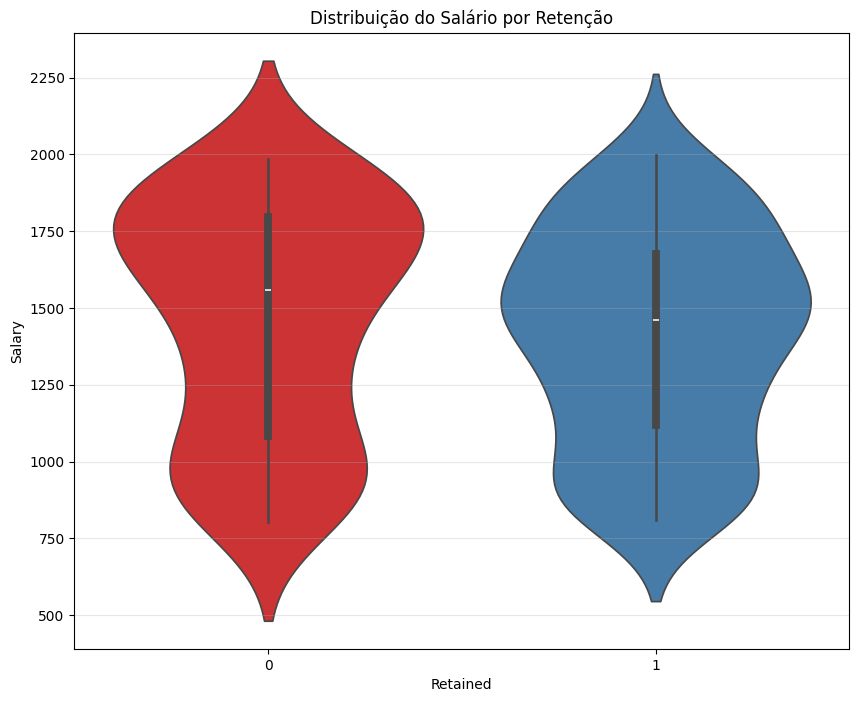

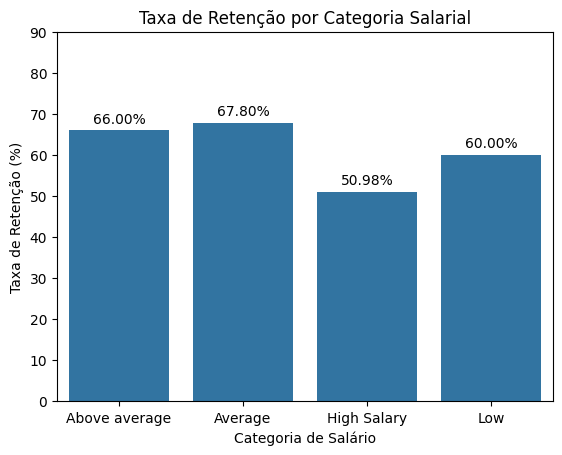

Salary_Rate
Above average    66.000000
Average          67.796610
High Salary      50.980392
Low              60.000000
Name: Retained, dtype: float64

In [12]:
df.head()

df["Salary_Rate"] = df.apply(lambda row: "Low" if row["Salary"] < 1000
                                            else
                                            "Above average" if row["Salary"] < 1424
                                            else
                                            "Average" if row["Salary"] < 1736
                                            else
                                            "High Salary", axis=1)
df.head(10)

plt.figure(figsize=(10,8))
sns.violinplot(
    data=df,
    x="Retained",
    y="Salary",
    palette="Set1"
)
plt.grid(axis="y", alpha=0.3)
plt.title("Distribuição do Salário por Retenção")
plt.show()


taxa_salario = df.groupby("Salary_Rate")["Retained"].mean()* 100 


ax = sns.barplot(x=taxa_salario.index, y=taxa_salario.values)
for container in ax.containers:
    ax.bar_label(container, padding=3, fmt="%.2f%%")
    plt.ylim(0, 90)
plt.ylabel("Taxa de Retenção (%)")
plt.xlabel("Categoria de Salário")
plt.title("Taxa de Retenção por Categoria Salarial")

plt.show()

display(taxa_salario)


### Retention Rate by Salary ###
*The **violin plot** indicates that the salary distributions between retained and non-retained interns are quite similar, suggesting that salary alone does not seem to have a strong influence on retention.*

*However, when analyzing salary categories, it is observed that retention is slightly higher among interns with Average and Above Average salaries, while the High Salary category has the lowest retention rate. This may indicate that additional factors, besides salary, influence the retention decision.*


# 10. Age Analysis and Retention

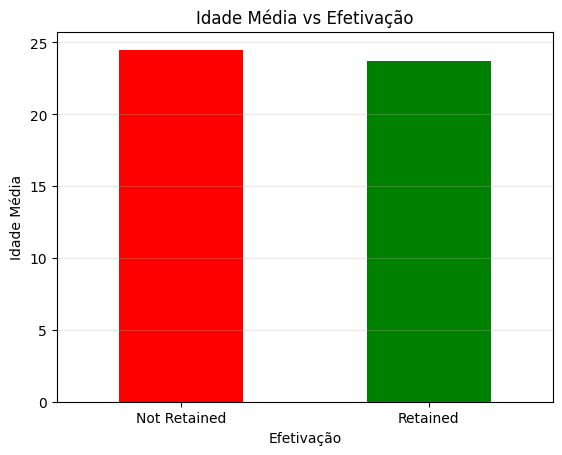

C:\Users\s3rgi\AppData\Local\Temp\ipykernel_31452\652342197.py:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(x="Retained", y="Age", data=df, palette="Set1")


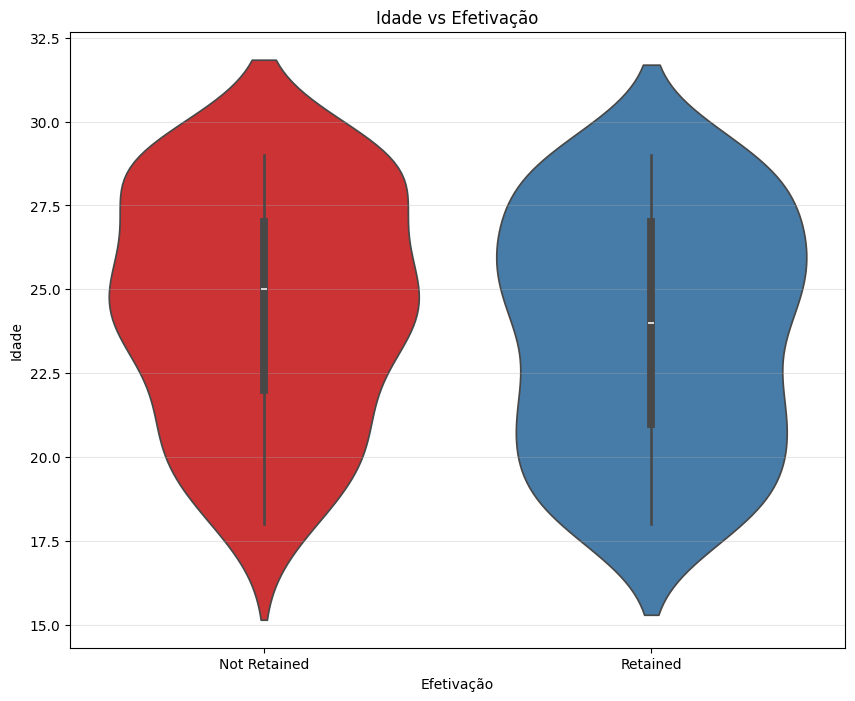

In [13]:
# Does age influence retention?

df.groupby("Retained")["Age"].mean().plot(kind="bar", color=["red", "green"])
plt.xlabel("Efetivação")
plt.ylabel("Idade Média")
plt.title("Idade Média vs Efetivação")
plt.xticks([0,1], ["Not Retained","Retained"], rotation=0)
plt.grid(axis='y', alpha=0.3)
plt.show()


plt.figure(figsize=(10,8))
sns.violinplot(x="Retained", y="Age", data=df, palette="Set1")
plt.xlabel("Efetivação")
plt.xticks([0,1], ["Not Retained","Retained"])
plt.ylabel("Idade")
plt.title("Idade vs Efetivação")
plt.grid(axis='y', alpha=0.3)
plt.show()

### Influence of Age on Intern Retention ###

*Analyzing the average age of retained and non-retained interns, we observed that the values ​​are quite similar. This suggests that age, in isolation, does not appear to be a determining factor for intern retention.*

*Analyzing the **violin plot**, we see a strong overlap between the age distributions of the two groups. Only a slight concentration of retained interns is observed between 25 and 27 years old, while non-retained interns show a slightly higher concentration between 23 and 25 years old.*

*However, these differences are small, reinforcing the indication that age does not seem to have a significant influence on the final retention of interns.*

# 11. Department Retention Analysis

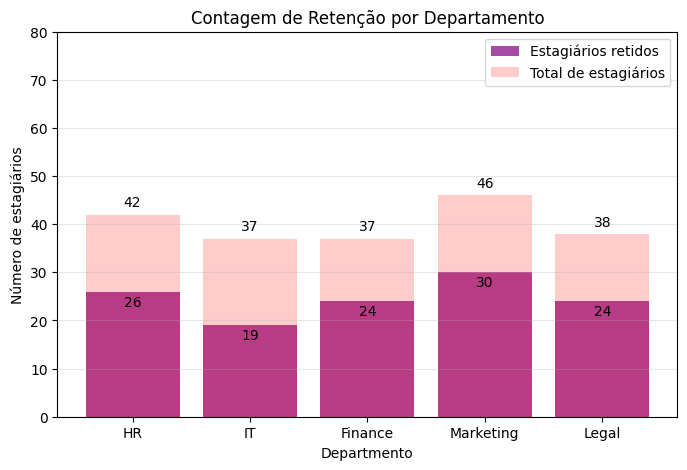

C:\Users\s3rgi\AppData\Local\Temp\ipykernel_31452\242307945.py:60: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ox = sns.barplot(x=data_retained_rate.keys(), y=data_retained_rate.values(), palette="Set1")


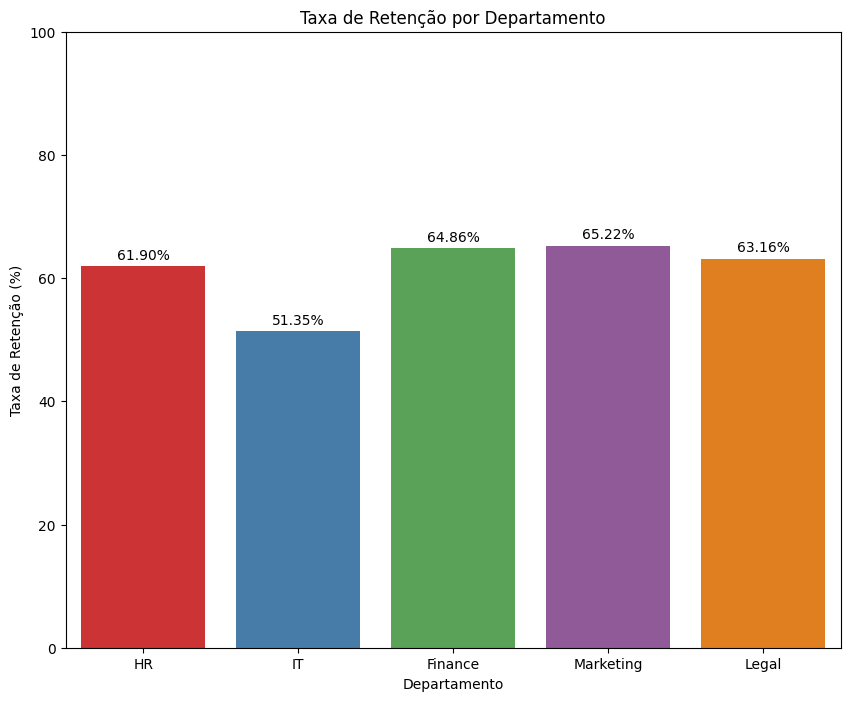

,Intern_ID,Age,Major,Internship_Duration_Months,Department,Supervisor_Evaluation,Salary,Attendance_%,Retained,Salary_Attendance_ratio,Evaluation_Flag,Salary_Rate
0,1,24,IT,20,Legal,1.8,1956,71.9,1,27.20,False,High Salary
1,2,21,Law,15,HR,1.2,1687,82.7,0,20.40,False,Average
2,3,28,Engineering,3,HR,1.7,926,79.0,0,11.72,False,Low
3,4,25,IT,23,Marketing,2.1,1929,86.5,1,22.30,False,High Salary
4,5,22,Engineering,8,Legal,1.7,1808,97.5,1,18.54,False,High Salary


In [14]:
# Analyze turnover by department

#df.groupby("Department")[["Evaluation_Flag", "Attendance_Flag"]].value_counts()
retained_department = df.groupby("Retained")["Department"].value_counts()


    
# Total number of trainees for each Department who were retained
retained_hr = len(df.loc[(df["Department"] == "HR") & (df["Retained"] == 1)])
retained_it = len(df.loc[(df["Department"] == "IT") & (df["Retained"] == 1)])
retained_finance = len(df.loc[(df["Department"] == "Finance") & (df["Retained"] == 1)])
retained_marketing = len(df.loc[(df["Department"] == "Marketing") & (df["Retained"] == 1)])
retained_legal = len(df.loc[(df["Department"] == "Legal") & (df["Retained"] == 1)])

# % of retained
retained_hr_rate = retained_hr * 100 / total_hr
retained_it_rate = retained_it * 100 / total_it
retained_finance_rate = retained_finance * 100 / total_finance
retained_marketing_rate = retained_marketing * 100 / total_marketing
retained_legal_rate = retained_legal * 100 / total_legal

# Dict for retention data by department.

data_retained = {
    "HR": retained_hr,
    "IT": retained_it,
    "Finance": retained_finance,
    "Marketing": retained_marketing,
    "Legal": retained_legal
}

data_retained_rate = {  
    "HR": retained_hr_rate,
    "IT": retained_it_rate,
    "Finance": retained_finance_rate,
    "Marketing": retained_marketing_rate,
    "Legal": retained_legal_rate
    
}

# Bar chart to compare the number of interns retained per department with the total number of interns in each department
plt.figure(figsize=(8, 5))
plt.grid(alpha=0.3, axis="y")
plt.bar(data_retained.keys(), data_retained.values(), alpha=0.7, color="purple", label = "Estagiários retidos")
plt.bar(data_total.keys(), data_total.values(), alpha=0.2, color="red", label = "Total de estagiários")
for x, y in enumerate(data_total.values()):
    plt.text(x, y + 1, str(y), ha='center', va='bottom', color="black")

for x, y in enumerate(data_retained.values()):
    plt.text(x, y - 3, str(y), ha='center')
plt.ylim(0,80)
plt.ylabel("Número de estagiários")
plt.xlabel("Departmento")
plt.title("Contagem de Retenção por Departamento")
plt.legend()
plt.show()

# Bar chart to compare retention rate by department
plt.figure(figsize=(10,8))
ox = sns.barplot(x=data_retained_rate.keys(), y=data_retained_rate.values(), palette="Set1")
for container in ox.containers:
    ox.bar_label(container, fmt="%.2f%%", padding=3)
plt.ylabel("Taxa de Retenção (%)")
plt.xlabel("Departamento")
plt.title("Taxa de Retenção por Departamento")
plt.ylim(0, 100)
plt.show()


df.head()

Retention Percentage:

HR: **61.90%**

IT: **51.35%**

Finance: **64.86%**

Marketing: **65.22%**

Legal: **63.16%**

*We can analyze from the graphs that the department with the highest intern retention is **Marketing** with **65.2%** of interns, while the department with the lowest is **IT** with **51.35%**.*

*This may indicate possible challenges in intern retention in the **IT** department when compared to other departments.*


# 12. Interactive Data Exploration

In [15]:
# Overview using the Widget


# Create a df drop to remove the "Evaluation Flag" column and create a new column to categorize supervisor evaluations.
df_drop = df.drop(columns=["Evaluation_Flag"])

# Create a new column to categorize reviews.

df_drop.head()

df_drop["Supervisor_Evaluation_Rank"] = df_drop.apply(lambda row: "Worst" if row["Supervisor_Evaluation"] < 2
                                            else
                                            "Above Average" if row["Supervisor_Evaluation"] < 3 
                                            else
                                            "Average" if row["Supervisor_Evaluation"] < 4
                                            else
                                            "Good" if row["Supervisor_Evaluation"] < 4.9
                                            else "Excellent", axis=1)
           
@interact(
    Retained = df_drop["Retained"].unique(),
    Department = df_drop["Department"].unique(),
    Evaluation = df_drop["Supervisor_Evaluation_Rank"].unique(),
       
)
def filter_data(Retained, Department, Evaluation): 
    display(df_drop[(df_drop["Retained"] == Retained) & (df_drop["Department"] == Department) & (df_drop["Supervisor_Evaluation_Rank"] == Evaluation)])
    
len(df_drop)

interactive(children=(Dropdown(description='Retained', options=(np.int64(1), np.int64(0)), value=np.int64(1)),…

200

# 12. Supervisor Evaluation vs Internship Duration

interactive(children=(Dropdown(description='Department', options=('Legal', 'HR', 'Marketing', 'Finance', 'IT')…

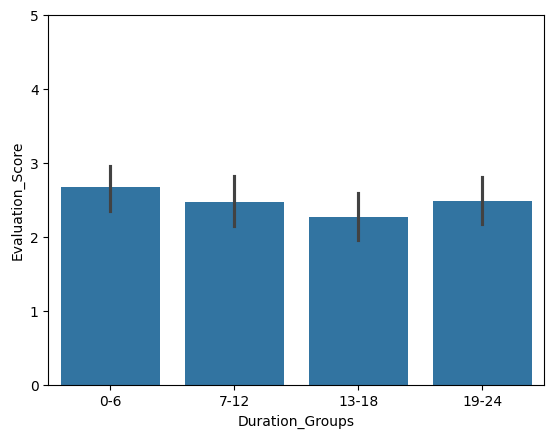

In [16]:
### Supervisor evalution based on internship duration ###

# List of categories for supervisor evaluation, where 1 is the worst evaluation and 5 is the best.
mapping = {
    "Worst": 1,
    "Above Average": 2,
    "Average": 3,
    "Good": 4,
    "Excellent": 5
} 

# Creating a new column to categorize the duration of the internship.

df_drop["Duration_Groups"] = pd.cut(df_drop["Internship_Duration_Months"], bins=[0,6,12,18,24], labels=["0-6", "7-12", "13-18", "19-24"])

# Column to qualify each category and use that number as a rank.
df_drop["Evaluation_Score"] = df_drop["Supervisor_Evaluation_Rank"].map(mapping)

@interact(
    #Retained = df_drop["Retained"].unique(),
    Department = df_drop["Department"].unique()
)

def update_chart(Department):

    filtered = df_drop[
        (df_drop["Department"] == Department)  
    ]

    plt.figure(figsize=(10,6))

    sns.boxplot(
        data=filtered,
        x="Duration_Groups",
        y="Evaluation_Score"
                
    )
    plt.yticks([1,2,3,4,5], ["Worst","Above Average","Average","Good","Excellent"])
    plt.grid(alpha=0.3, axis="y")
    plt.title("Avaliação do Supervisor por Duração do Estágio")
    plt.xlabel("Duração do Estágio (Meses)")
    plt.ylabel("Avaliação do Supervisor")
    plt.show()
    
plt.figure()
sns.barplot(data=df_drop, x="Duration_Groups", y="Evaluation_Score")
plt.ylim(0, 5)
plt.show()

### Supervisors' Evaluation of Internship Duration ###
**Legal**:
*The distribution of evaluations shows a slight decrease in the median rating as the internship duration increases.*

**HR**:
*A slight drop in the median is observed between 0-6 and 7-12 months, followed by a gradual recovery in evaluations until the 19-24 month period.*

**Marketing**:
*Evaluations show a decrease in the median until the 13-18 month period, followed by a recovery in the final period (19-24 months).*

**Finance**:
*The distribution of evaluations remains relatively stable across the different periods, with a slight increase in the median in the 19-24 month range.*

**IT**:
*Evaluations show a slight initial increase until the 13-18 month period, followed by a decrease in the final period (19-24 months).*

# Analysis

*The analysis concluded that intern retention is influenced by multiple factors, although not all have the same impact. There are no significant differences in the number of interns with above- or below-average evaluations, and overall, supervisor evaluations show similar distributions between retained and non-retained interns, suggesting a limited influence on the final decision.*

*Department emerged as a relevant factor, with Marketing showing the highest retention rate (65.22%) and IT the lowest (51.35%), which may reflect differences in working conditions, expectations, or management practices. Differences were also observed across academic majors, with Engineering having the highest retention rate and Marketing the lowest.*

*Internship duration appears to have a positive impact on retention, as longer internships tend to increase the likelihood of retention. However, the relationship between duration and supervisor evaluation varies across departments and is not consistent.*

*Regarding salary, although distributions are similar between groups, slightly higher retention is observed in intermediate salary categories, suggesting that salary alone is not a determining factor. Similarly, age does not appear to have a significant influence on retention.*

*Overall, intern retention results from a combination of factors, with department, field of study, and internship duration playing a more prominent role, while variables such as evaluation, salary, and age have a more limited impact when considered individually.*